# Ensemble Correlation Analysis

This notebook analyzes correlations between susceptibilities and cost eigenvectors for the trained ensemble.

**Analyses:**
1. Correlations between susceptibilities and cost eigenvectors
2. Susceptibilities at different strains
3. Cost eigenvectors from individual hessians
4. Different kinds of susceptibilities (parallel, perp, eq)
5. Relative susceptibility (ratio at different strains)
6. Relative susceptibility vs relative cost eigenvector

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import copy

# Add paths
sys.path.append('../ensemble_training')
sys.path.append('../instruments')

from task_generator import generate_task_config, get_all_task_configs
from config import N_TASKS, N_NODES, BOUNDARY_MARGIN, FORCE_TYPE, N_STRAIN_STEPS
from network_utils import create_auxetic_network, get_square_boundary_nodes
from elastic_network import ElasticNetwork
from training_functions_with_toggle import (
    compute_quasistatic_trajectory_auxetic,
    compute_poisson_ratio_single,
    fire_minimize_network
)
from generalized_susceptibility import (
    compute_physical_hessian_strained,
    compute_full_jacobian_matrixwise,
    precompute_geometry
)
from fire_minimize_memview_cy import fire_minimize_dof

import jax
jax.config.update("jax_enable_x64", True)

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Configuration
DATA_DIR = Path('../data/auxetic_nets')
print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Data directory: ../data/auxetic_nets
Exists: True


## Data Loading Utilities

In [3]:
def discover_tasks(data_dir):
    """Find all task directories in data_dir."""
    data_dir = Path(data_dir)
    tasks = []
    for d in sorted(data_dir.iterdir()):
        if d.is_dir() and d.name.startswith('task_'):
            task_seed = int(d.name.split('_')[1])
            tasks.append(task_seed)
    return tasks


def discover_realizations(task_seed, data_dir):
    """Find all completed realizations for a given task."""
    data_dir = Path(data_dir)
    task_dir = data_dir / f'task_{task_seed:02d}'
    realizations = []
    
    if not task_dir.exists():
        return realizations
    
    for d in sorted(task_dir.iterdir()):
        if d.is_dir() and d.name.startswith('realization_'):
            if (d / 'loss_trajectory.npy').exists():
                real_seed = int(d.name.split('_')[1])
                realizations.append(real_seed)
    
    return realizations


def load_trajectories(task_seed, realization_seed, data_dir):
    """Load loss and stiffness trajectories from .npy files."""
    data_dir = Path(data_dir)
    path = data_dir / f'task_{task_seed:02d}' / f'realization_{realization_seed:02d}'
    
    loss = np.load(path / 'loss_trajectory.npy')
    stiffness = np.load(path / 'stiffness_trajectory.npy')
    
    return loss, stiffness


def reconstruct_network_for_task(task_seed, n_nodes=N_NODES, boundary_margin=BOUNDARY_MARGIN):
    """
    Reconstruct the network for a given task using packing_seed = task_seed.
    """
    network, boundary_dict = create_auxetic_network(
        n_nodes=n_nodes,
        packing_seed=task_seed,
        boundary_margin=boundary_margin
    )
    return network, boundary_dict

## Core Analysis Functions

In [4]:
def compute_s_parallel_perp_eq(network, top_nodes, bottom_nodes, force_type='quadratic', tol=1e-15):
    """
    Compute susceptibility tensor components for a network at its current state.
    
    Returns:
        s_parallel: (E,) - parallel component trace per edge
        s_perp: (E,) - perpendicular component trace per edge  
        s_eq: (E,) - equilibrium coupling component trace per edge
    """
    # Set up constrained DOFs (y-direction for top and bottom nodes)
    constrained_idx_dof = []
    for i in np.concatenate([top_nodes, bottom_nodes]):
        constrained_idx_dof.append(i * 2 + 1)  # y DOF
    
    # Compute physical Hessian
    physical_hessian = compute_physical_hessian_strained(
        stiffnesses=network.stiffnesses,
        rest_lengths=network.rest_lengths,
        edges=np.array(network.edges),
        final_positions=network.positions,
        constrained_idx_dof=constrained_idx_dof,
        tol=tol,
        force_type=force_type
    )
    
    # Create mask for free DOFs
    mask_free = np.ones(physical_hessian.shape[0], dtype=bool)
    mask_free[constrained_idx_dof] = False
    
    # Build extended Hessian with constraints
    N_n = len(network.positions)
    constrain_nodes_01 = np.zeros((3, 2 * N_n))
    constrain_nodes_01[0, 0] = 1  # Fix x of node 0
    for idx, node in enumerate(top_nodes):
        constrain_nodes_01[1, 2 * node + 1] = 1
    for idx, node in enumerate(bottom_nodes):
        constrain_nodes_01[2, 2 * node + 1] = 1
    
    extended_physical_hessian = np.block([
        [physical_hessian, constrain_nodes_01.T],
        [constrain_nodes_01, np.zeros((3, 3))]
    ])
    
    # Invert Hessians
    H_ff_inv = np.linalg.inv(physical_hessian[np.ix_(mask_free, mask_free)])
    H_inv = np.linalg.inv(extended_physical_hessian)[:-3, :-3]
    
    # Compute Jacobian
    Hjac, Hjac_parts, (Δ, V, l, n, Pp) = compute_full_jacobian_matrixwise(
        network.positions, 
        network.edges, 
        network.stiffnesses, 
        network.rest_lengths,
        H_ff_inv, 
        mask=mask_free, 
        d=2, 
        H_full_inv=H_inv.reshape((N_n, 2, N_n, 2))
    )
    
    N_e = len(network.stiffnesses)
    
    # Extract components and compute traces
    H1 = Hjac_parts['H1'].reshape(N_e, 2*N_n, 2*N_n)
    H2 = Hjac_parts['H2'].reshape(N_e, 2*N_n, 2*N_n)
    H3 = Hjac_parts['H3'].reshape(N_e, 2*N_n, 2*N_n)
    H4 = Hjac_parts['H4'].reshape(N_e, 2*N_n, 2*N_n)
    
    # Susceptibility = -H components, take trace
    s_parallel = -np.trace(H1, axis1=1, axis2=2)
    s_perp = -np.trace(H2, axis1=1, axis2=2)
    s_eq = -np.trace(H3 + H4, axis1=1, axis2=2)
    
    return np.array(s_parallel), np.array(s_perp), np.array(s_eq)

In [5]:
def compute_cost_hessian_single_subtask(network, target_poisson, compression_strain,
                                        top_nodes, bottom_nodes, left_nodes, right_nodes,
                                        epsilon=1e-5, n_strain_steps=20, force_type='quadratic'):
    """
    Compute the Hessian of the loss function w.r.t. stiffnesses for a single subtask.
    
    Loss = (attained_poisson - target_poisson)^2
    
    Uses finite differences (5-point stencil for mixed partials is expensive,
    so we use diagonal + sample off-diagonal for efficiency).
    
    Returns:
        hessian: (n_edges, n_edges) matrix (or diagonal approximation)
    """
    n_edges = len(network.stiffnesses)
    base_k = np.copy(network.stiffnesses)
    
    def loss_fn(stiffnesses):
        net_copy = copy.deepcopy(network)
        net_copy.stiffnesses = stiffnesses
        pr = compute_poisson_ratio_single(
            net_copy, top_nodes, bottom_nodes, left_nodes, right_nodes,
            compression_strain, n_strain_steps=n_strain_steps, force_type=force_type
        )
        return (pr - target_poisson) ** 2
    
    # Compute diagonal of Hessian (second derivatives)
    hessian_diag = np.zeros(n_edges)
    L_center = loss_fn(base_k)
    
    for i in tqdm(range(n_edges), desc='Computing Hessian diagonal', leave=False):
        k_plus = base_k.copy()
        k_plus[i] += epsilon
        k_minus = base_k.copy()
        k_minus[i] -= epsilon
        
        L_plus = loss_fn(k_plus)
        L_minus = loss_fn(k_minus)
        
        hessian_diag[i] = (L_plus - 2*L_center + L_minus) / (epsilon**2)
    
    return hessian

In [6]:
def metrics(a, b):
    """Compute cosine similarity and Pearson correlation between two vectors."""
    a = np.array(a).ravel()
    b = np.array(b).ravel()
    
    # Cosine similarity
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-16 or norm_b < 1e-16:
        cos = 0.0
    else:
        cos = np.dot(a, b) / (norm_a * norm_b)
    
    # Pearson correlation
    if np.std(a) < 1e-16 or np.std(b) < 1e-16:
        pearson = 0.0
    else:
        pearson = np.corrcoef(a, b)[0, 1]
    
    return cos, pearson


def safe_normalize(v):
    """Normalize a vector, handling zero norm."""
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 1e-16 else v

In [7]:
def plot_network_edge_colored(network, edge_values, ax=None, cmap='viridis', 
                              vmin=None, vmax=None, title=None, use_log=False):
    """Plot network with edges colored by a scalar value."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    positions = np.array(network.positions)
    edges = np.array(network.edges)
    
    if vmin is None:
        vmin = edge_values.min()
    if vmax is None:
        vmax = edge_values.max()
    
    if use_log:
        norm = plt.matplotlib.colors.LogNorm(vmin=max(vmin, 1e-10), vmax=vmax)
    else:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    for idx, (i, j) in enumerate(edges):
        color = sm.to_rgba(edge_values[idx])
        ax.plot([positions[i, 0], positions[j, 0]], 
                [positions[i, 1], positions[j, 1]], 
                color=color, linewidth=2)
    
    ax.scatter(positions[:, 0], positions[:, 1], c='black', s=20, zorder=3)
    plt.colorbar(sm, ax=ax)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title)
    
    return ax

## Load Data and Select Realizations for Analysis

In [8]:
# Discover available data
tasks = discover_tasks(DATA_DIR)
print(f"Found {len(tasks)} tasks: {tasks}")

# Select tasks and realizations to analyze
# NOTE: Full correlation analysis is expensive - start with a few realizations
TASKS_TO_ANALYZE = tasks[:2]  # First 2 tasks
MAX_REALIZATIONS_PER_TASK = 2  # 2 realizations per task

analysis_candidates = []
for task in TASKS_TO_ANALYZE:
    realizations = discover_realizations(task, DATA_DIR)[:MAX_REALIZATIONS_PER_TASK]
    for real in realizations:
        analysis_candidates.append((task, real))

print(f"\nWill analyze {len(analysis_candidates)} realizations:")
for task, real in analysis_candidates:
    print(f"  Task {task}, Realization {real}")

Found 6 tasks: [0, 1, 2, 3, 4, 5]

Will analyze 4 realizations:
  Task 0, Realization 0
  Task 0, Realization 1
  Task 1, Realization 0
  Task 1, Realization 1


## Run Full Correlation Analysis

In [9]:
def analyze_single_realization(task_seed, realization_seed, data_dir=DATA_DIR,
                                n_strain_steps=20, force_type='quadratic'):
    """
    Full analysis pipeline for one trained network.
    
    Returns a dictionary with all computed quantities.
    """
    # Load trajectories and get best stiffness
    loss, stiffness = load_trajectories(task_seed, realization_seed, data_dir)
    best_step = np.argmin(loss)
    best_stiffness = stiffness[best_step]
    
    # Get task configuration
    task_config = generate_task_config(task_seed)
    compression_strains = task_config['compression_strains']
    target_poissons = task_config['target_poisson_ratios']
    
    # Reconstruct network with best stiffnesses
    network, boundary_dict = reconstruct_network_for_task(task_seed)
    network.stiffnesses = np.array(best_stiffness)
    
    top_nodes = boundary_dict['top']
    bottom_nodes = boundary_dict['bottom']
    left_nodes = boundary_dict['left']
    right_nodes = boundary_dict['right']
    
    results = {
        'task_seed': task_seed,
        'realization_seed': realization_seed,
        'min_loss': loss[best_step],
        'network': copy.deepcopy(network),
        'subtasks': []
    }
    
    # Analyze each subtask
    for subtask_idx, (cs, tp) in enumerate(zip(compression_strains, target_poissons)):
        print(f"  Subtask {subtask_idx}: compression={cs}, target_poisson={tp}")
        
        # Apply compression strain to get strained state
        net_copy = copy.deepcopy(network)
        traj = compute_quasistatic_trajectory_auxetic(
            net_copy, cs, top_nodes, bottom_nodes,
            n_steps=n_strain_steps, verbose=False, force_type=force_type, tol=1e-9
        )
        
        # Network at strained state
        strained_network = copy.deepcopy(network)
        strained_network.positions = np.copy(traj[-1])
        
        # Compute susceptibility at strained state
        s_parallel, s_perp, s_eq = compute_s_parallel_perp_eq(
            strained_network, top_nodes, bottom_nodes, force_type=force_type
        )
        s_total = s_parallel + s_perp + s_eq
        
        # Compute cost Hessian for this subtask
        print(f"    Computing cost Hessian...")
        cost_hessian = compute_cost_hessian_single_subtask(
            network, tp, cs, 
            top_nodes, bottom_nodes, left_nodes, right_nodes,
            epsilon=1e-8, n_strain_steps=n_strain_steps, force_type=force_type
        )
        
        # Extract eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cost_hessian + cost_hessian.T)
        eigenvector_top = np.abs(eigenvectors[:, -1])  # Top eigenvector
        

        # Compute correlations
        sus_norm = safe_normalize(np.abs(s_total))
        eigvec_norm = safe_normalize(eigenvector_top)
        cos_sim, pearson = metrics(sus_norm, eigvec_norm)
        
        subtask_result = {
            'subtask_idx': subtask_idx,
            'compression_strain': cs,
            'target_poisson': tp,
            'susceptibility_parallel': s_parallel,
            'susceptibility_perp': s_perp,
            'susceptibility_eq': s_eq,
            'susceptibility_total': s_total,
            'cost_hessian': cost_hessian,
            'cost_eigenvalues': eigenvalues,
            'cost_eigenvectors': eigenvectors,
            'cosine_similarity': cos_sim,
            'pearson_correlation': pearson,
            'strained_positions': traj[-1]
        }
        results['subtasks'].append(subtask_result)
    
    return results

In [10]:
# Run analysis on selected realizations
all_analysis_results = []

for task, real in tqdm(analysis_candidates, desc='Analyzing realizations'):
    print(f"\nAnalyzing task {task}, realization {real}...")
    try:
        result = analyze_single_realization(task, real)
        all_analysis_results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()

print(f"\nSuccessfully analyzed {len(all_analysis_results)} realizations")

Analyzing realizations:   0%|          | 0/4 [00:00<?, ?it/s]


Analyzing task 0, realization 0...


progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]


  Subtask 0: compression=-0.08, target_poisson=-0.25
    Computing cost Hessian...


  Subtask 1: compression=-0.03, target_poisson=-0.5
    Computing cost Hessian...


...

progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]


  Subtask 0: compression=-0.09, target_poisson=-0.3
    Computing cost Hessian...


  Subtask 1: compression=-0.03, target_poisson=-0.5
    Computing cost Hessian...


Analyzing realizations: 100%|██████████| 4/4 [04:53<00:00, 73.28s/it]


Successfully analyzed 4 realizations


## Analysis 1: Susceptibility vs Cost Eigenvector Correlations

In [11]:
# Collect correlation metrics
correlation_data = []

for result in all_analysis_results:
    for subtask in result['subtasks']:
        correlation_data.append({
            'task': result['task_seed'],
            'realization': result['realization_seed'],
            'subtask': subtask['subtask_idx'],
            'compression_strain': subtask['compression_strain'],
            'target_poisson': subtask['target_poisson'],
            'cosine_similarity': subtask['cosine_similarity'],
            'pearson_correlation': subtask['pearson_correlation']
        })

df_corr = pd.DataFrame(correlation_data)
print("Correlation statistics:")
print(df_corr[['cosine_similarity', 'pearson_correlation']].describe())

Correlation statistics:
       cosine_similarity  pearson_correlation
count           8.000000             8.000000
mean            0.178908             0.168439
std             0.255699             0.262042
min             0.005483            -0.010411
25%             0.030261             0.016579
50%             0.106119             0.092356
75%             0.166683             0.156731
max             0.782855             0.787361


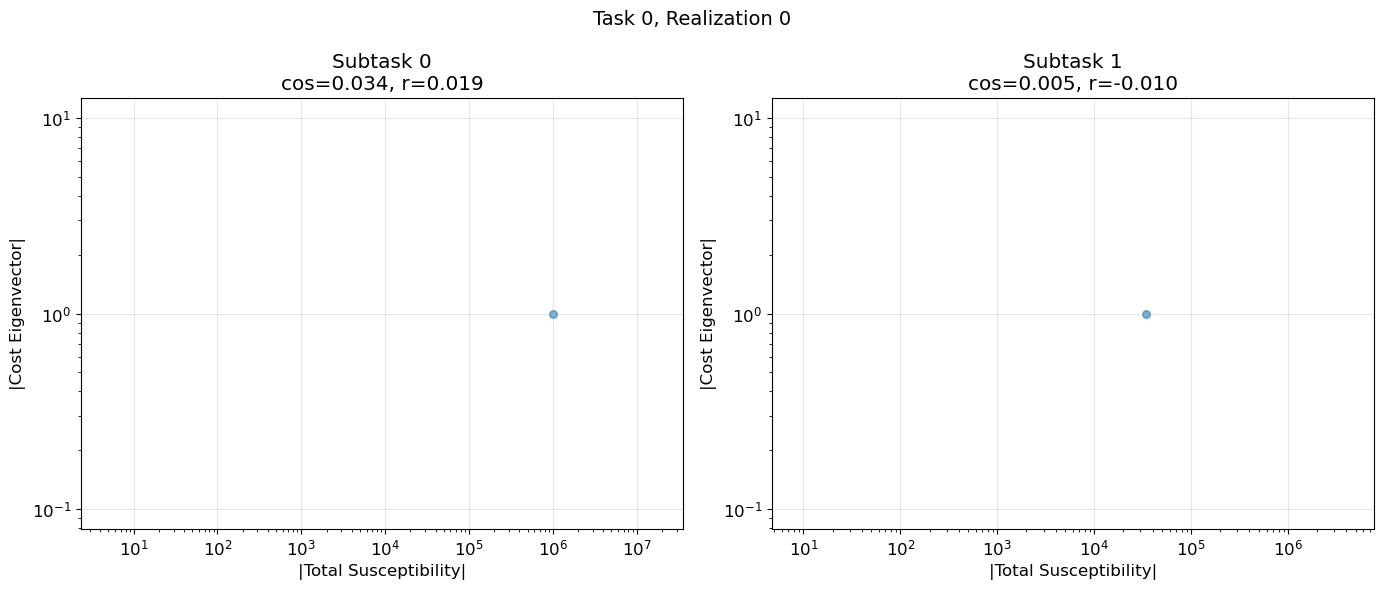

In [12]:
# Scatter plot: susceptibility vs eigenvector for one example
if len(all_analysis_results) > 0:
    example_result = all_analysis_results[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for subtask_idx, subtask in enumerate(example_result['subtasks']):
        ax = axes[subtask_idx]
        
        sus = np.abs(subtask['susceptibility_total'])
        eig = subtask['cost_eigenvector_top']
        
        ax.scatter(sus, eig, alpha=0.6, s=30)
        ax.set_xlabel('|Total Susceptibility|')
        ax.set_ylabel('|Cost Eigenvector|')
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        cos = subtask['cosine_similarity']
        pearson = subtask['pearson_correlation']
        ax.set_title(f'Subtask {subtask_idx}\ncos={cos:.3f}, r={pearson:.3f}')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Task {example_result["task_seed"]}, Realization {example_result["realization_seed"]}', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()

## Analysis 2: Susceptibilities at Different Strains

In [13]:
def compare_susceptibilities_across_strains(result):
    """Compare susceptibility patterns between subtask 0 and subtask 1."""
    if len(result['subtasks']) < 2:
        return None
    
    s0 = result['subtasks'][0]
    s1 = result['subtasks'][1]
    
    comparisons = {}
    
    # Compare total susceptibilities
    cos_total, pearson_total = metrics(s0['susceptibility_total'], s1['susceptibility_total'])
    comparisons['total'] = {'cos': cos_total, 'pearson': pearson_total}
    
    # Compare individual components
    cos_par, _ = metrics(s0['susceptibility_parallel'], s1['susceptibility_parallel'])
    cos_perp, _ = metrics(s0['susceptibility_perp'], s1['susceptibility_perp'])
    cos_eq, _ = metrics(s0['susceptibility_eq'], s1['susceptibility_eq'])
    
    comparisons['parallel'] = cos_par
    comparisons['perp'] = cos_perp
    comparisons['eq'] = cos_eq
    
    return comparisons

In [14]:
# Compare susceptibilities across strains
cross_strain_data = []

for result in all_analysis_results:
    comparison = compare_susceptibilities_across_strains(result)
    if comparison:
        cross_strain_data.append({
            'task': result['task_seed'],
            'realization': result['realization_seed'],
            'cos_total': comparison['total']['cos'],
            'cos_parallel': comparison['parallel'],
            'cos_perp': comparison['perp'],
            'cos_eq': comparison['eq']
        })

df_cross_strain = pd.DataFrame(cross_strain_data)
print("Cross-strain susceptibility correlations:")
print(df_cross_strain.describe())

Cross-strain susceptibility correlations:
          task  realization  cos_total  cos_parallel  cos_perp    cos_eq
count  4.00000      4.00000   4.000000      4.000000  4.000000  4.000000
mean   0.50000      0.50000   0.429740      0.569630  0.079770  0.201762
std    0.57735      0.57735   0.436918      0.055608  0.670177  0.525267
min    0.00000      0.00000  -0.073075      0.504285 -0.867055 -0.342267
25%    0.00000      0.00000   0.133034      0.533469 -0.157281 -0.194262
50%    0.50000      0.50000   0.488218      0.575886  0.299542  0.207988
75%    1.00000      1.00000   0.784924      0.612047  0.536593  0.604012
max    1.00000      1.00000   0.815600      0.622465  0.587049  0.733338


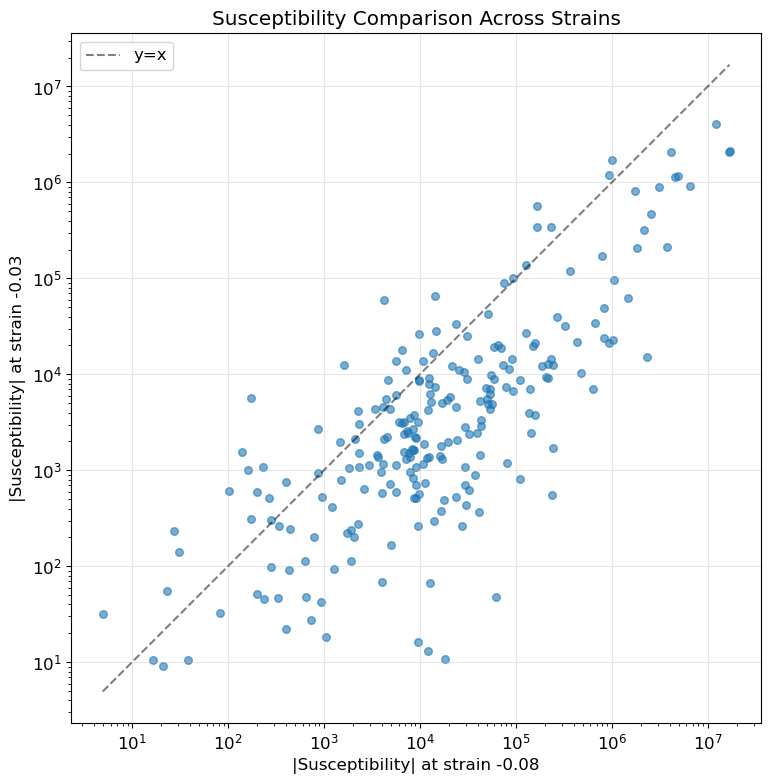

In [15]:
# Scatter: susceptibility at strain 1 vs strain 2
if len(all_analysis_results) > 0:
    example_result = all_analysis_results[0]
    
    if len(example_result['subtasks']) >= 2:
        s0 = example_result['subtasks'][0]
        s1 = example_result['subtasks'][1]
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        sus0 = np.abs(s0['susceptibility_total'])
        sus1 = np.abs(s1['susceptibility_total'])
        
        ax.scatter(sus0, sus1, alpha=0.6, s=30)
        
        # Diagonal line
        lims = [min(sus0.min(), sus1.min()), max(sus0.max(), sus1.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
        
        ax.set_xlabel(f'|Susceptibility| at strain {s0["compression_strain"]}')
        ax.set_ylabel(f'|Susceptibility| at strain {s1["compression_strain"]}')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title('Susceptibility Comparison Across Strains')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()

## Analysis 3: Cost Eigenvectors from Individual Hessians

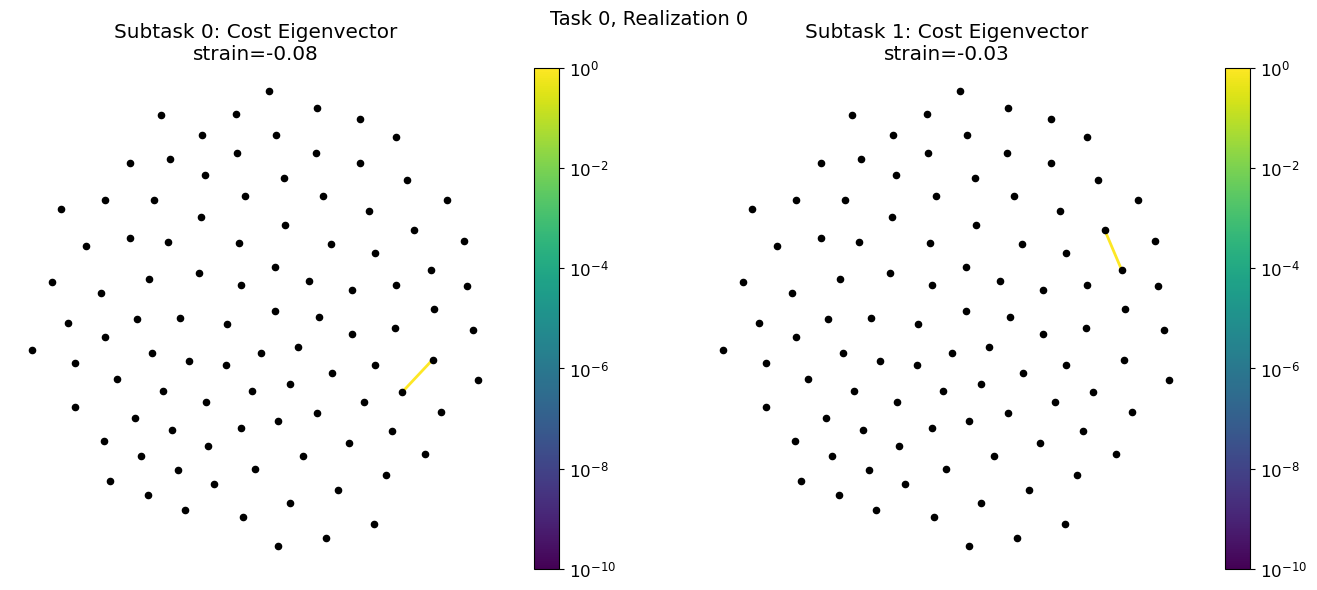

In [27]:
# Visualize network colored by eigenvector magnitude
if len(all_analysis_results) > 0:
    example_result = all_analysis_results[0]
    network = example_result['network']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for subtask_idx, subtask in enumerate(example_result['subtasks']):
        eigvec = subtask['cost_eigenvector_top']
        
        plot_network_edge_colored(
            network, np.abs(eigvec), ax=axes[subtask_idx],
            cmap='viridis', use_log=True,
            title=f'Subtask {subtask_idx}: Cost Eigenvector\nstrain={subtask["compression_strain"]}'
        )
    
    plt.suptitle(f'Task {example_result["task_seed"]}, Realization {example_result["realization_seed"]}',
                 fontsize=14)
    plt.tight_layout()
    plt.show()

## Analysis 4: Different Susceptibility Components

In [17]:
def analyze_susceptibility_components(subtask_result):
    """
    Analyze relative contributions of different susceptibility components.
    """
    s_par = subtask_result['susceptibility_parallel']
    s_perp = subtask_result['susceptibility_perp']
    s_eq = subtask_result['susceptibility_eq']
    eigvec = subtask_result['cost_eigenvector_top']
    
    # Magnitudes
    mag_par = np.linalg.norm(s_par)
    mag_perp = np.linalg.norm(s_perp)
    mag_eq = np.linalg.norm(s_eq)
    total_mag = mag_par + mag_perp + mag_eq
    
    # Correlations with eigenvector
    cos_par_eig, _ = metrics(np.abs(s_par), eigvec)
    cos_perp_eig, _ = metrics(np.abs(s_perp), eigvec)
    cos_eq_eig, _ = metrics(np.abs(s_eq), eigvec)
    
    return {
        'magnitude_parallel': mag_par / total_mag if total_mag > 0 else 0,
        'magnitude_perp': mag_perp / total_mag if total_mag > 0 else 0,
        'magnitude_eq': mag_eq / total_mag if total_mag > 0 else 0,
        'cos_parallel_vs_eigenvector': cos_par_eig,
        'cos_perp_vs_eigenvector': cos_perp_eig,
        'cos_eq_vs_eigenvector': cos_eq_eig
    }

In [18]:
# Analyze susceptibility components for all subtasks
component_data = []

for result in all_analysis_results:
    for subtask in result['subtasks']:
        comp_analysis = analyze_susceptibility_components(subtask)
        component_data.append({
            'task': result['task_seed'],
            'realization': result['realization_seed'],
            'subtask': subtask['subtask_idx'],
            **comp_analysis
        })

df_components = pd.DataFrame(component_data)
print("Susceptibility component analysis:")
print(df_components.describe())

Susceptibility component analysis:
           task  realization   subtask  magnitude_parallel  magnitude_perp  \
count  8.000000     8.000000  8.000000            8.000000        8.000000   
mean   0.500000     0.500000  0.500000            0.360907        0.104985   
std    0.534522     0.534522  0.534522            0.170122        0.098239   
min    0.000000     0.000000  0.000000            0.032262        0.008958   
25%    0.000000     0.000000  0.000000            0.313390        0.040743   
50%    0.500000     0.500000  0.500000            0.395094        0.076594   
75%    1.000000     1.000000  1.000000            0.458535        0.134963   
max    1.000000     1.000000  1.000000            0.569254        0.312375   

       magnitude_eq  cos_parallel_vs_eigenvector  cos_perp_vs_eigenvector  \
count      8.000000                     8.000000                 8.000000   
mean       0.534107                     0.196780                 0.201693   
std        0.228294            

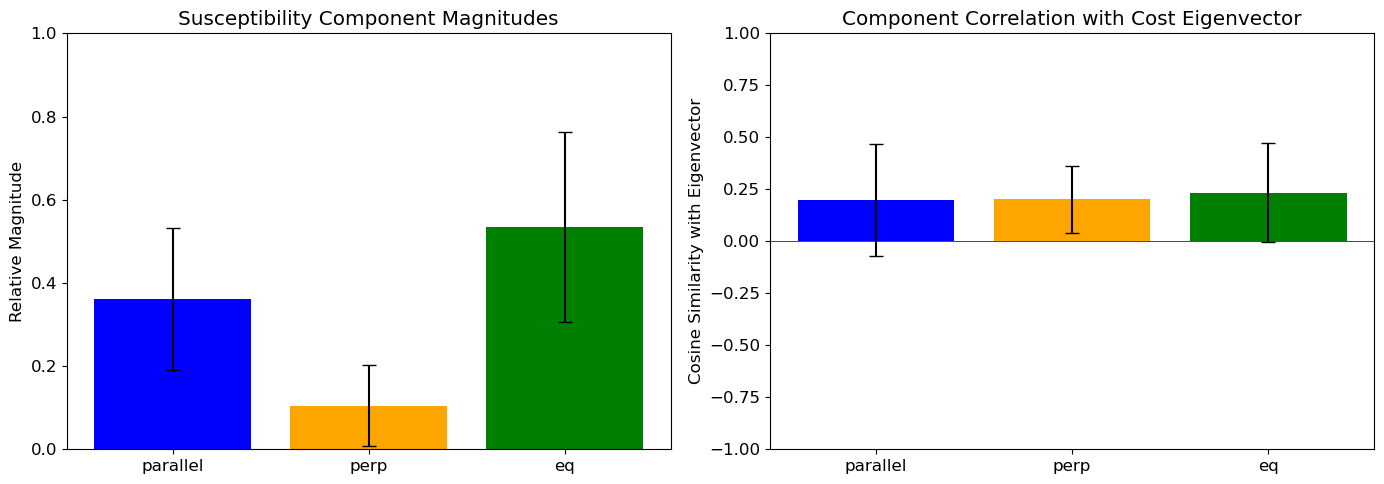

In [19]:
# Bar chart of component contributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Magnitude contributions
ax = axes[0]
components = ['parallel', 'perp', 'eq']
means = [df_components[f'magnitude_{c}'].mean() for c in components]
stds = [df_components[f'magnitude_{c}'].std() for c in components]
ax.bar(components, means, yerr=stds, capsize=5, color=['blue', 'orange', 'green'])
ax.set_ylabel('Relative Magnitude')
ax.set_title('Susceptibility Component Magnitudes')
ax.set_ylim(0, 1)

# Correlation with eigenvector
ax = axes[1]
cors = [df_components[f'cos_{c}_vs_eigenvector'].mean() for c in components]
cors_std = [df_components[f'cos_{c}_vs_eigenvector'].std() for c in components]
ax.bar(components, cors, yerr=cors_std, capsize=5, color=['blue', 'orange', 'green'])
ax.set_ylabel('Cosine Similarity with Eigenvector')
ax.set_title('Component Correlation with Cost Eigenvector')
ax.set_ylim(-1, 1)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## Analysis 5: Relative Susceptibility

In [20]:
def compute_relative_susceptibility(result):
    """
    Compute ratio: susceptibility(subtask_0) / susceptibility(subtask_1) for each edge.
    """
    if len(result['subtasks']) < 2:
        return None, None
    
    s0 = np.abs(result['subtasks'][0]['susceptibility_total'])
    s1 = np.abs(result['subtasks'][1]['susceptibility_total'])
    
    # Avoid division by zero
    relative_sus = s0 / (s1 + 1e-16)
    log_relative_sus = np.log10(relative_sus + 1e-16)
    
    return relative_sus, log_relative_sus

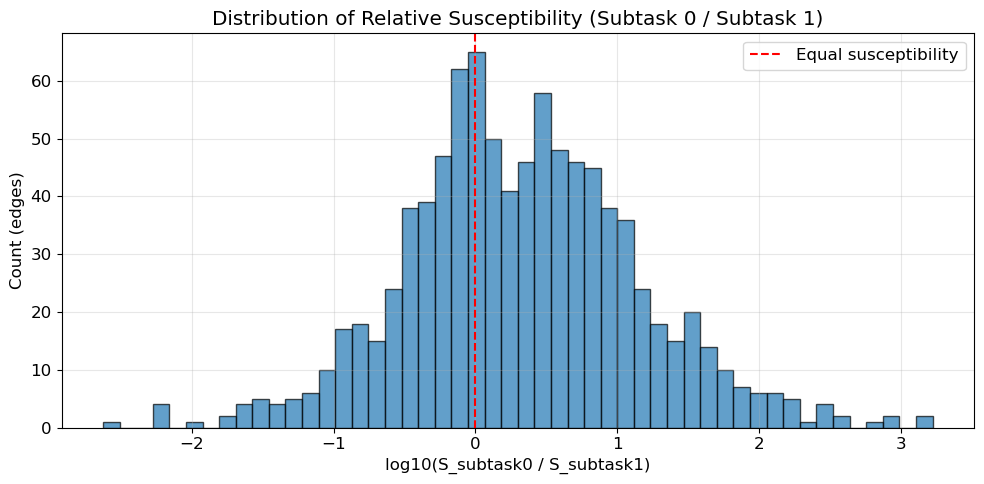

In [21]:
# Compute relative susceptibility for all realizations
relative_sus_data = []

for result in all_analysis_results:
    rel_sus, log_rel_sus = compute_relative_susceptibility(result)
    if rel_sus is not None:
        result['relative_susceptibility'] = rel_sus
        result['log_relative_susceptibility'] = log_rel_sus
        relative_sus_data.extend(log_rel_sus.tolist())

# Histogram of log-ratios
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(relative_sus_data, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Equal susceptibility')
ax.set_xlabel('log10(S_subtask0 / S_subtask1)')
ax.set_ylabel('Count (edges)')
ax.set_title('Distribution of Relative Susceptibility (Subtask 0 / Subtask 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

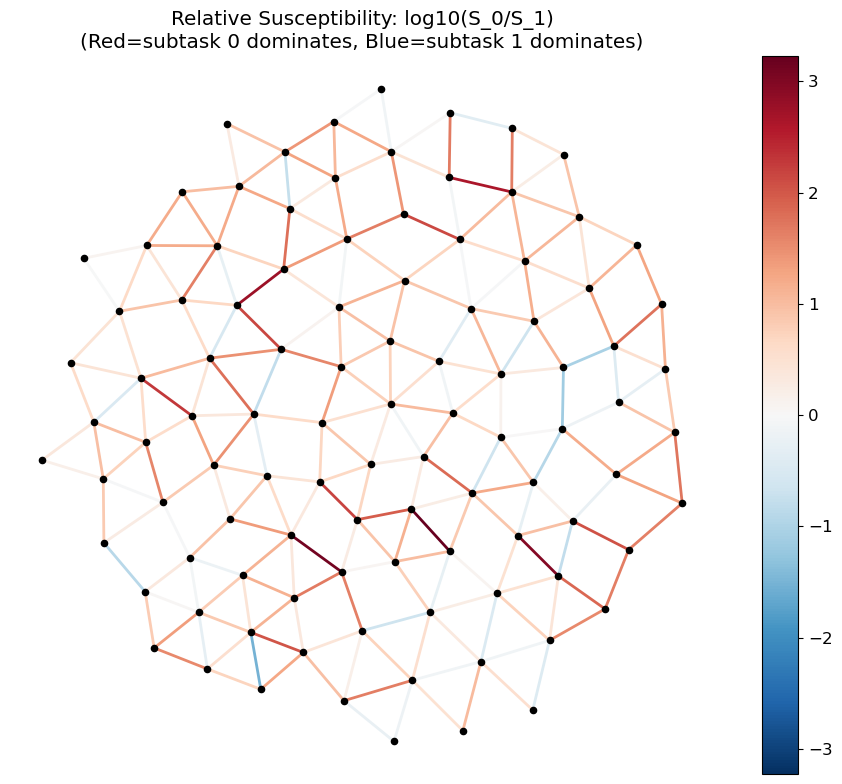

In [22]:
# Visualize network colored by relative susceptibility
if len(all_analysis_results) > 0 and 'relative_susceptibility' in all_analysis_results[0]:
    example_result = all_analysis_results[0]
    network = example_result['network']
    log_rel_sus = example_result['log_relative_susceptibility']
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use symmetric colormap around 0
    vmax = max(abs(log_rel_sus.min()), abs(log_rel_sus.max()))
    
    plot_network_edge_colored(
        network, log_rel_sus, ax=ax,
        cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        title=f'Relative Susceptibility: log10(S_0/S_1)\n(Red=subtask 0 dominates, Blue=subtask 1 dominates)'
    )
    
    plt.tight_layout()
    plt.show()

## Analysis 6: Relative Susceptibility vs Relative Cost Eigenvector

In [23]:
def compute_relative_eigenvector(result):
    """
    Compute ratio: |eigenvector_0| / |eigenvector_1| for each edge.
    """
    if len(result['subtasks']) < 2:
        return None, None
    
    eig0 = np.abs(result['subtasks'][0]['cost_eigenvector_top'])
    eig1 = np.abs(result['subtasks'][1]['cost_eigenvector_top'])
    
    relative_eig = eig0 / (eig1 + 1e-16)
    log_relative_eig = np.log10(relative_eig + 1e-16)
    
    return relative_eig, log_relative_eig


def analyze_relative_correlation(result):
    """
    Compare relative susceptibility with relative cost eigenvector importance.
    """
    rel_sus, log_rel_sus = compute_relative_susceptibility(result)
    rel_eig, log_rel_eig = compute_relative_eigenvector(result)
    
    if rel_sus is None or rel_eig is None:
        return None
    
    cos_sim, pearson = metrics(log_rel_sus, log_rel_eig)
    
    return {
        'relative_susceptibility': rel_sus,
        'relative_eigenvector': rel_eig,
        'log_relative_susceptibility': log_rel_sus,
        'log_relative_eigenvector': log_rel_eig,
        'cosine_similarity': cos_sim,
        'pearson_correlation': pearson
    }

In [24]:
# Analyze relative correlation for all realizations
relative_analysis_results = []

for result in all_analysis_results:
    rel_analysis = analyze_relative_correlation(result)
    if rel_analysis:
        relative_analysis_results.append({
            'task': result['task_seed'],
            'realization': result['realization_seed'],
            **rel_analysis
        })

# Summary statistics
if len(relative_analysis_results) > 0:
    cos_vals = [r['cosine_similarity'] for r in relative_analysis_results]
    pearson_vals = [r['pearson_correlation'] for r in relative_analysis_results]
    
    print("Relative Susceptibility vs Relative Eigenvector Correlations:")
    print(f"  Cosine similarity: mean={np.mean(cos_vals):.3f}, std={np.std(cos_vals):.3f}")
    print(f"  Pearson correlation: mean={np.mean(pearson_vals):.3f}, std={np.std(pearson_vals):.3f}")

Relative Susceptibility vs Relative Eigenvector Correlations:
  Cosine similarity: mean=-0.333, std=0.290
  Pearson correlation: mean=-0.022, std=0.061


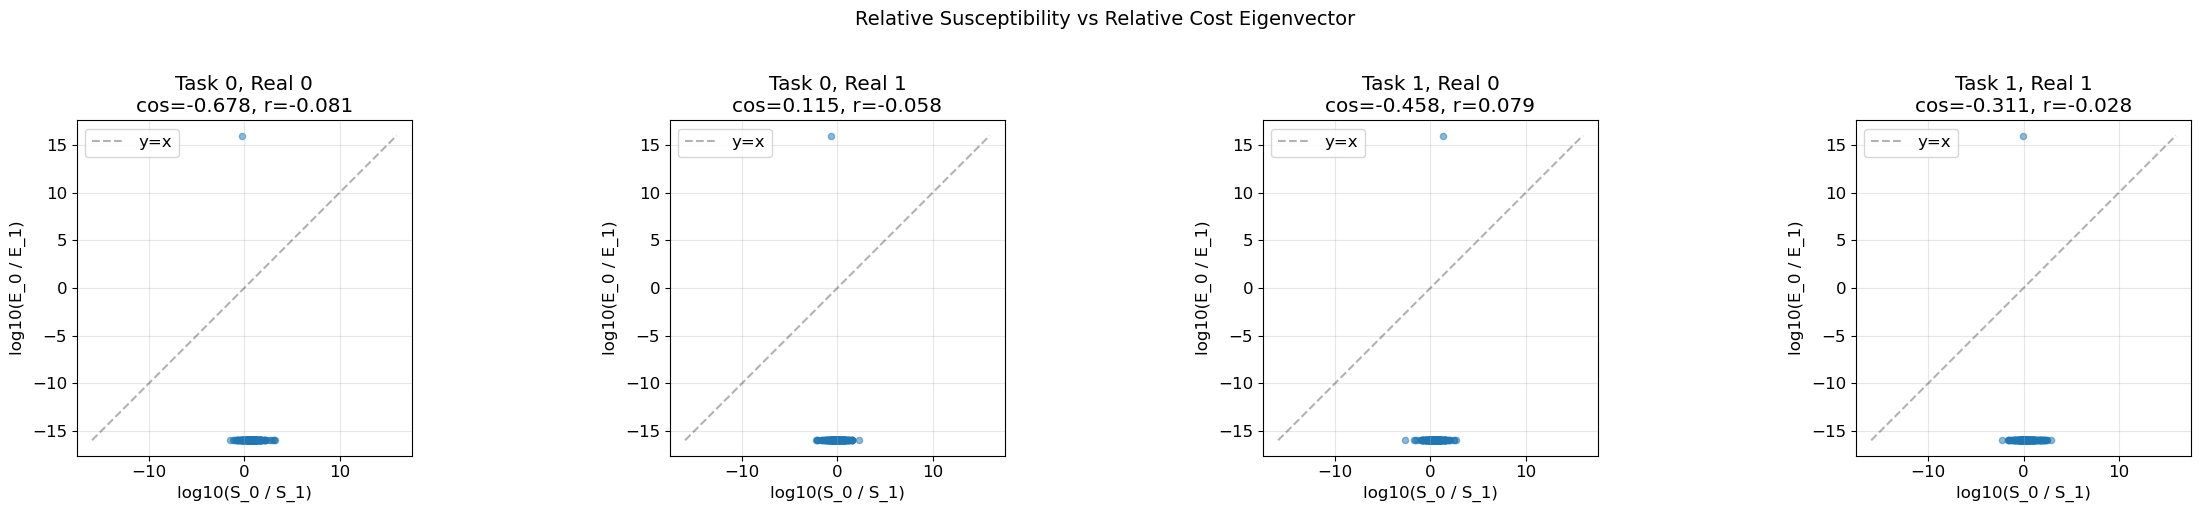

In [25]:
# Scatter plot: relative susceptibility vs relative eigenvector
if len(relative_analysis_results) > 0:
    fig, axes = plt.subplots(1, len(relative_analysis_results), 
                             figsize=(6*len(relative_analysis_results), 5))
    if len(relative_analysis_results) == 1:
        axes = [axes]
    
    for idx, rel_result in enumerate(relative_analysis_results):
        ax = axes[idx]
        
        log_sus = rel_result['log_relative_susceptibility']
        log_eig = rel_result['log_relative_eigenvector']
        
        ax.scatter(log_sus, log_eig, alpha=0.5, s=20)
        
        # Diagonal line
        lims = [min(log_sus.min(), log_eig.min()), max(log_sus.max(), log_eig.max())]
        ax.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
        
        ax.set_xlabel('log10(S_0 / S_1)')
        ax.set_ylabel('log10(E_0 / E_1)')
        
        cos = rel_result['cosine_similarity']
        pearson = rel_result['pearson_correlation']
        ax.set_title(f'Task {rel_result["task"]}, Real {rel_result["realization"]}\ncos={cos:.3f}, r={pearson:.3f}')
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_aspect('equal')
    
    plt.suptitle('Relative Susceptibility vs Relative Cost Eigenvector', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Summary

In [26]:
print("="*70)
print("ENSEMBLE CORRELATION ANALYSIS SUMMARY")
print("="*70)

print(f"\nRealizations analyzed: {len(all_analysis_results)}")

if len(df_corr) > 0:
    print(f"\n1. Susceptibility-Eigenvector Correlations:")
    print(f"   Mean cosine similarity: {df_corr['cosine_similarity'].mean():.3f}")
    print(f"   Mean Pearson correlation: {df_corr['pearson_correlation'].mean():.3f}")

if len(df_cross_strain) > 0:
    print(f"\n2. Cross-strain susceptibility consistency:")
    print(f"   Mean cosine (total): {df_cross_strain['cos_total'].mean():.3f}")

if len(df_components) > 0:
    print(f"\n3. Susceptibility component analysis:")
    print(f"   Parallel magnitude fraction: {df_components['magnitude_parallel'].mean():.3f}")
    print(f"   Perpendicular magnitude fraction: {df_components['magnitude_perp'].mean():.3f}")
    print(f"   Equilibrium magnitude fraction: {df_components['magnitude_eq'].mean():.3f}")

if len(relative_analysis_results) > 0:
    print(f"\n4. Relative susceptibility vs relative eigenvector:")
    cos_vals = [r['cosine_similarity'] for r in relative_analysis_results]
    print(f"   Mean cosine similarity: {np.mean(cos_vals):.3f}")
    print(f"   (Positive correlation means edges important for subtask 0")
    print(f"    have higher susceptibility for subtask 0 vs subtask 1)")

print("="*70)

ENSEMBLE CORRELATION ANALYSIS SUMMARY

Realizations analyzed: 4

1. Susceptibility-Eigenvector Correlations:
   Mean cosine similarity: 0.179
   Mean Pearson correlation: 0.168

2. Cross-strain susceptibility consistency:
   Mean cosine (total): 0.430

3. Susceptibility component analysis:
   Parallel magnitude fraction: 0.361
   Perpendicular magnitude fraction: 0.105
   Equilibrium magnitude fraction: 0.534

4. Relative susceptibility vs relative eigenvector:
   Mean cosine similarity: -0.333
   (Positive correlation means edges important for subtask 0
    have higher susceptibility for subtask 0 vs subtask 1)
